The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


 lower bound 201.72003406334176:  12%|▍   | 1041/9000 [48:21<6:09:44,  2.79s/it]


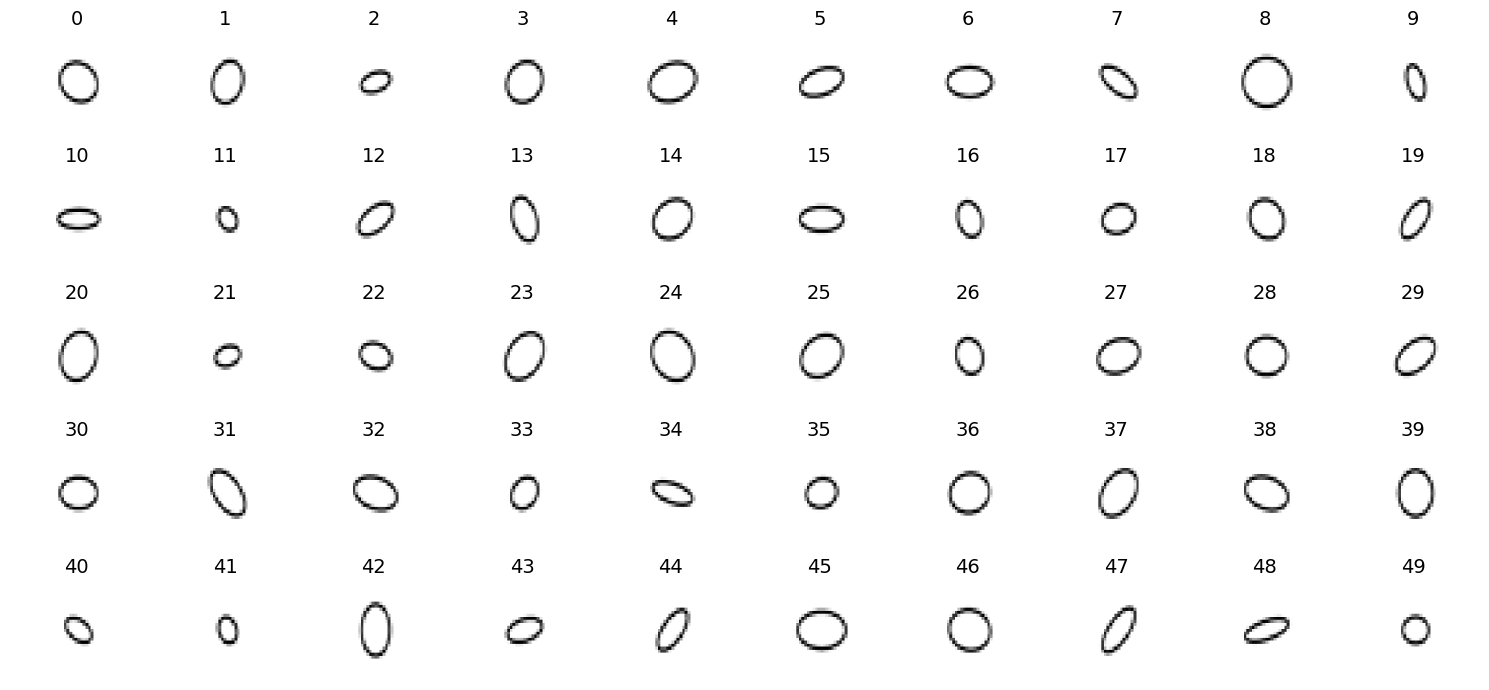

In [70]:
%load_ext autoreload
%autoreload 2
import sys,os
sys.path.append('../')   
import numpy as np
import pandas as pd
from model.erroneousChoice import erroneousChoice
from kernel.jaxrbf import RBF
from utility import  paramz
from sklearn.model_selection import  GroupShuffleSplit
import pickle
import torch
from botorch.utils.multi_objective import is_non_dominated
import os
from PIL import Image
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal


# Function to resize an image to 150x150
def resize_image(image_path):
    with Image.open(image_path) as img:
        resized_img = img.resize((150, 150))
    return resized_img
    
def is_pareto(X):
    return is_non_dominated(torch.from_numpy(X),deduplicate=False)

def accuracy_choice(CA,RA,U):
    #using pseudo-rationality
    acc=[]
    for r in RA:
        acc.append(np.any(U[CA,:]-U[r,:]>0,axis=1))
    acc.append(is_pareto(np.array(U[CA,:])).tolist())
    return acc
    
# Folder containing your images
folder_path = 'datasets/ellipse/'


# Create a 5x10 grid for visualization
fig, axes = plt.subplots(5, 10, figsize=(15, 7), subplot_kw={'xticks': [], 'yticks': []})

# Adjust the spacing and remove the box around the images
plt.subplots_adjust(wspace=0, hspace=-1)
for ax in axes.flat:
    ax.xaxis.set_major_locator(plt.NullLocator())
    ax.yaxis.set_major_locator(plt.NullLocator())
    ax.set_aspect('auto')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)

# Loop through the images and display them in the grid with titles
for i, ax in enumerate(axes.flat):
    if i < 50:
        image_path = os.path.join(folder_path, "ellipse"+str(i)+".png")
        resized_img = resize_image(image_path)
        ax.imshow(resized_img, extent=[0, 1, 0, 1], aspect='auto', interpolation='none', cmap='gray')
        ax.set_title(str(i), fontsize=14)  # Set the image id as the title

plt.tight_layout()

# Save the figure as a PDF
#output_path = 'allellipses.pdf'
#plt.savefig(output_path, format='pdf', bbox_inches='tight')
#plt.show()

# Choosing ellipses
We generated 50 images of random ellipses as shown in the figure above. As it can be seen, these ellipses differ in  dimension and orientation relative to the coordinate axes. We assigned a task to a student involving selecting ellipses based on two criteria: (i) small eccentricity (being close to a circular shape); (ii) alignment of their axes with the Cartesian axes. It was emphasised to the student that, in case of incomparability due to conflicting criteria, multiple choices were acceptable.  Note that, we decreased the resolution of the images to make this task harder.  The student repeated this task 160 times generating a dataset including 160 choices, for example fiven the ellipses with ID in $A_1=\{6,35,36\}$, the student selected $C(A_1)=\{6\}$. Given the ellipses in $A_2=\{37,42,47\}$ the student selected $C(A_2)=\{37,42\}$. We will load the dataset hereafter.


In [71]:
user_choices=[]
set_choices=[]
with open(r"datasets/ellipse/ellipses_user_choices", "rb") as output_file:
        user_choices=pickle.load(output_file)
with open(r"datasets/ellipse/ellipses_set_choices", "rb") as output_file:
        set_choices=pickle.load(output_file)
#info about the ellipses
df = pd.read_csv("datasets/ellipse/data.csv",index_col = 0)
#df = df.iloc[:,0:3]#flatten images #df.iloc[:,5:]/255-0.5#flatten images
#chosen ellipses
CA = user_choices
#rejected ellipses
RA = [np.setdiff1d(set_choices[i],user_choices[i]).tolist() for i in range(len(set_choices))]
print(list(zip(CA[1:5],RA[1:5])))#each tuple is a choosing task

[([6], [36, 47]), ([42, 37], [47]), ([3], [12, 20]), ([39, 41], [44])]


In [72]:
#only got plot
plottingcases = True
ind_test1 =[14,81,91]
ind_train1=np.setdiff1d(np.arange(len(CA)),ind_te)

In [7]:
'''
np.random.seed(1)
Util=df[['rotation','ecc_sq']].values
Util[:,0]=np.min(abs(Util[:,[0]]-np.linspace(0,2*np.pi,9)),axis=1)
CA=[]
RA=[]
for i in range(160):
    cr=np.random.permutation(np.arange(50))[0:3]
    ind=np.argmin(Util[cr]+np.random.randn(3,2)*0.01,axis=0)
    ca = cr[np.unique(ind)]
    CA.append(ca)
    RA.append(np.setdiff1d(cr,ca).tolist())
'''

"\nnp.random.seed(1)\nUtil=df[['rotation','ecc_sq']].values\nUtil[:,0]=np.min(abs(Util[:,[0]]-np.linspace(0,2*np.pi,9)),axis=1)\nCA=[]\nRA=[]\nfor i in range(160):\n    cr=np.random.permutation(np.arange(50))[0:3]\n    ind=np.argmin(Util[cr]+np.random.randn(3,2)*0.01,axis=0)\n    ca = cr[np.unique(ind)]\n    CA.append(ca)\n    RA.append(np.setdiff1d(cr,ca).tolist())\n"

We use this dataset ($50$ images $25\times 25$ pixels and $160$ choices) to learn the latent utilities through Model 9 in the tutorial paper with pseudo-rational likelihood (since we do not know if the student used Pareto-dominance). The dataset was partitioned into 90\% for training and 10\% for testing using 10-fold cross-validation, and we computed the accuracy in predicting the student's choices. Hereafter, we only run  CV 5 times for simplicity.

In [74]:
n_splits=1
splitter = GroupShuffleSplit(train_size=0.90, n_splits=n_splits, random_state = 42)
split = splitter.split(CA, groups=np.arange(len(CA)))
X = df.values/255
Res=[]
for cv in range(n_splits):
    print(cv)
    #prepare data
    if plottingcases==False:
        ind_train, ind_test = next(split)
    else:
         ind_train, ind_test =  ind_train1, ind_test1
    CA_tr=[CA[i] for i in ind_train]
    RA_tr=[RA[i] for i in ind_train]
    CA_te=[CA[i] for i in ind_test]
    RA_te=[RA[i] for i in ind_test]
    
    
    dimA = 3#each choice set has dimension 3
    #choice data
    data={'X': X,#objects
          'CA': CA_tr,#choiced objects
          'RA': RA_tr,#rejected objects
          'dimA':dimA# dimension of the choice set
              }
    # number of latent utilities, it is known
    latent_dim=2
    
    # define kernel 
    Kernel = RBF
    #hyperparameters of the kernel
    params = {'lengthscale_0': {'value':0.35*np.ones(data["X"].shape[1],float), 
                                    'range':np.vstack([[0.1, 5.0]]*data["X"].shape[1]),
                                    'transform': paramz.logexp()},
                   'variance_0': {'value':np.array([1]), 
                                    'range':np.vstack([[0.05, 50.0]]),
                                    'transform': paramz.logexp()},
              
                  'lengthscale_1': {'value':0.35*np.ones(data["X"].shape[1],float), 
                                    'range':np.vstack([[0.1, 5.0]]*data["X"].shape[1]),
                                    'transform': paramz.logexp()},
                   'variance_2': {'value':np.array([0.1]), 
                                    'range':np.vstack([[0.05, 50.0]]),
                                    'transform': paramz.logexp()}
                      }

    
    
    
    # define choice model 
    model = erroneousChoice(data,Kernel,params,latent_dim,jitter=1e-6,typeR="pseudo")
    
    # compute variational inference and estimate hyperparameters
    model.optimize_hyperparams(niterations=9000,kernel_hypers_fixed=False)
    
    
    print(model.params)

    #prediction
    predictions = model.predict_VI(X)
    meanu=predictions[0]
    Sigmau=predictions[1]
    

    
    #sample
    ns = 100
    samples = multivariate_normal(meanu[:,0],Sigmau+1e-5*np.eye(Sigmau.shape[0])).rvs(ns)

    
    #compute accuracy
    meanu=np.array(meanu)
    Acc = []
    for i in range(len(CA_te)):
        for j in range(len(RA_te[i])):
            Acc=Acc+np.array([np.any(meanu[CA_te[i],:]-meanu[RA_te[i][j]]>0)]).tolist()
           
        Acc=Acc+is_pareto(np.array(meanu[CA_te[i],:])).tolist()
    
    Res.append(np.mean(Acc))
    
    


0
200.5253508498303


 lower bound 166.04071166264856: 100%|██████| 9000/9000 [42:39<00:00,  3.52it/s]

{'lengthscale_0': {'value': array([2.09598597e+01, 9.19253061e-01, 4.50958286e+00, 9.91978485e+00,
       1.03930554e+02, 3.50000000e-01, 3.50000000e-01, 3.50000000e-01,
       3.50000000e-01, 3.50000000e-01, 3.50000000e-01, 3.50000000e-01,
       3.50000000e-01, 3.50000000e-01, 3.50000000e-01, 3.50000000e-01,
       3.50000000e-01, 3.50000000e-01, 3.50000000e-01, 3.50000000e-01,
       3.50000000e-01, 3.50000000e-01, 3.50000000e-01, 3.50000000e-01,
       3.50000000e-01, 3.50000000e-01, 3.50000000e-01, 3.50000000e-01,
       3.50000000e-01, 3.50000000e-01, 3.50000000e-01, 3.50000000e-01,
       3.50000000e-01, 3.50000000e-01, 3.50000000e-01, 3.50000000e-01,
       3.50000000e-01, 3.50000000e-01, 3.50000000e-01, 3.50000000e-01,
       3.50000000e-01, 3.50000000e-01, 3.50000000e-01, 3.50000000e-01,
       3.50000000e-01, 3.50000000e-01, 3.50000000e-01, 3.50000000e-01,
       3.50000000e-01, 3.50000000e-01, 3.50000000e-01, 3.50000000e-01,
       3.50000000e-01, 3.50000000e-01, 3.50000000

([35], [27, 41])


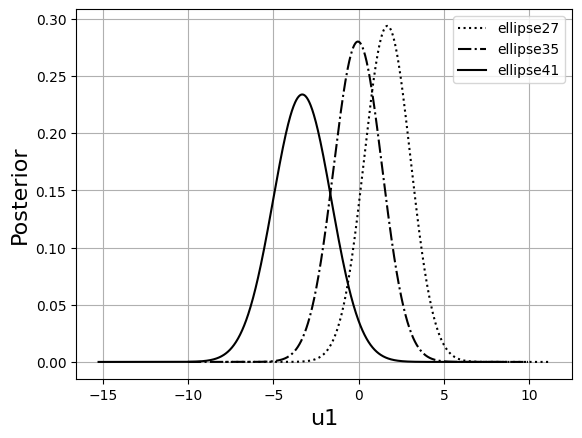

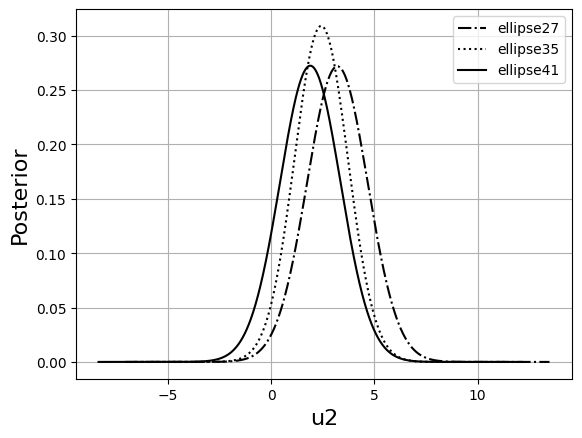

In [91]:
from scipy.stats import norm
mean1=predictions[0][0:X.shape[0],:]
Sigma1=predictions[1][0:X.shape[0],0:X.shape[0]]
mean2=predictions[0][X.shape[0]:,:]
Sigma2=predictions[1][X.shape[0]:,X.shape[0]:]
ii=2
ind=np.union1d(CA_te[ii],RA_te[ii]).astype(int) #([39], [19, 34])
print((CA_te[ii],RA_te[ii]))
col=[':','-.','-']
j=-1
for i in ind:
    j=j+1
    m1=mean1[i]
    s1=np.sqrt(Sigma1[i,i])
    xx = np.linspace(m1 - 7*s1,m1+7*s1, 1000)
    yy = norm.pdf(xx, m1, s1)
    plt.plot(xx, yy,color='black',linestyle=col[j],label="ellipse"+str(i))
plt.xlabel("u1",fontsize=16)
plt.legend()
plt.grid()
plt.ylabel("Posterior",fontsize=16)
#plt.savefig("figures/ellipseu5.pdf")

plt.figure()
j=-1
for i in ind:
    j=j+1
    m1=mean2[i]
    s1=np.sqrt(Sigma2[i,i])
    xx = np.linspace(m1 - 7*s1,m1+7*s1, 1000)
    yy = norm.pdf(xx, m1, s1)
    plt.plot(xx, yy,color='black',linestyle=col[j],label="ellipse"+str(i))
plt.xlabel("u2",fontsize=16)
plt.legend()
plt.grid()
plt.ylabel("Posterior",fontsize=16)
#plt.savefig("ellipseu6.pdf")
#az.plot_dist(predictions[0]-predictions[2])
#plt.savefig("figures/ellipseu6.pdf")